# Fase 5: Conclusiones y Productivización

Cierre del TFM: un prototipo que convierte transacciones crudas en una decisión de retención,
y la lectura de negocio de todo el pipeline.

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import inspect

import sys
from pathlib import Path
sys.path.insert(0, str(Path("..") / "src"))  # tfm_pipeline.py vive en src/, no junto al notebook
import tfm_pipeline as tfm

tfm.setup_notebook(seaborn_style=False)

with open('../models/models_fase3.pkl', 'rb') as f:
    fase3 = pickle.load(f)
with open('../models/models_clv.pkl', 'rb') as f:
    faseclv = pickle.load(f)

FEATURES = fase3['feature_columns']
THRESHOLD = fase3['threshold']
CLV_MEDIAN = faseclv['clv_median']
# Toda constante del esquema temporal se lee del pickle: nada se redeclara a mano.
LOOKBACK_MONTHS = fase3['lookback_months']
HORIZON_DAYS = fase3['horizon_days']

modelo_churn = fase3[f"{fase3['best_model_key']}_best"]
modelo_clv = faseclv[f"{faseclv['best_model_key']}_best"]
NOMBRE_CHURN = fase3['model_names'][fase3['best_model_key']]
NOMBRE_CLV = faseclv['model_names'][faseclv['best_model_key']]

transacciones = pd.read_csv('../data/processed/online_retail_II_cleaned.csv', parse_dates=['InvoiceDate'])
transacciones['Customer ID'] = transacciones['Customer ID'].astype(int)

print(f"Churn: {NOMBRE_CHURN} · umbral {THRESHOLD:.3f}")
print(f"CLV  : {NOMBRE_CLV} · corte de valor £{CLV_MEDIAN:,.0f}")
print(f"Ventana: {LOOKBACK_MONTHS} meses de histórico · horizonte {HORIZON_DAYS} días")
print(f"Transacciones disponibles: {len(transacciones):,}")

Churn: XGBoost · umbral 0.375
CLV  : LightGBM · corte de valor £574
Ventana: 6 meses de histórico · horizonte 90 días
Transacciones disponibles: 824,355


## Prototipo de scoring

Recibe **transacciones crudas** —no features precalculadas— y devuelve una decisión.
Así es como funcionaría conectado a un feed de pedidos.

`tfm.customer_features()` no reimplementa la lógica de la Fase 2: llama al **mismo núcleo de
cálculo** (`_aggregate_features`) que usó `build_window()` para entrenar. Es la diferencia
entre un prototipo que *parece* consistente con el entrenamiento y uno que lo es por
construcción — el desajuste entre las features de entrenamiento y las de producción
(*training-serving skew*) es el fallo silencioso más común al llevar un modelo a producción.

In [2]:
# El cálculo de features y la transformación se importan del módulo compartido:
# no hay ninguna copia de esta lógica en el notebook.
calcular_features = tfm.customer_features
preprocess = tfm.preprocess

print(inspect.getsource(tfm.customer_features))

def customer_features(transacciones: pd.DataFrame,
                      customer_id: int,
                      as_of_date,
                      lookback_months: int = LOOKBACK_MONTHS) -> dict | None:
    """Features de UN cliente a una fecha arbitraria, para scoring en producción.

    Reutiliza `_aggregate_features`, el mismo núcleo que `build_window`: el
    prototipo de la Fase 5 no puede calcular las features de otra forma que el
    entrenamiento. Devuelve None si el cliente no tiene compras en la ventana.
    """
    as_of_date = pd.to_datetime(as_of_date)
    inicio = as_of_date - pd.DateOffset(months=lookback_months)

    past = transacciones[(transacciones['Customer ID'] == customer_id) &
                         (transacciones['InvoiceDate'] >= inicio) &
                         (transacciones['InvoiceDate'] < as_of_date)]

    w = _aggregate_features(past, as_of_date)
    if w.empty:
        return None

    return {col: w.iloc[0][col] for col in FEATURES}



In [3]:
# La regla de decisión (riesgo -> CLV -> acción) vive en tfm_pipeline.score_customer():
# el notebook y la API HTTP llaman a la MISMA implementación, igual que customer_features().
# Si hubiera dos copias podrían desincronizarse, y el modelo recibiría en producción unas
# variables distintas de las que aprendió.
ACCIONES = tfm.ACCIONES


def scorear(features):
    return tfm.score_customer(features, fase3, faseclv)


def scorear_cliente(transacciones, customer_id, as_of_date):
    return tfm.score_customer_from_transactions(
        transacciones, customer_id, as_of_date, fase3, faseclv, LOOKBACK_MONTHS)


print("Prototipo listo: tfm.customer_features() -> tfm.score_customer()")

Prototipo listo: tfm.customer_features() -> tfm.score_customer()


### Demostración sobre clientes reales

`as_of_date` simula el «hoy» de producción: el día siguiente a la última transacción del dataset.
El modelo sólo ve los 6 meses anteriores a esa fecha.

In [4]:
as_of = transacciones['InvoiceDate'].max() + pd.Timedelta(days=1)

# Se muestrea entre los clientes SCOREABLES (con compras en la ventana), para que la
# demostración tenga siempre el número de filas anunciado.
scoreables = transacciones.loc[
    (transacciones['InvoiceDate'] >= as_of - pd.DateOffset(months=LOOKBACK_MONTHS)) &
    (transacciones['Quantity'] > 0), 'Customer ID'].unique()
muestra = pd.Series(scoreables).sample(8, random_state=7).tolist()

resultados = {cid: scorear_cliente(transacciones, cid, as_of) for cid in muestra}

filas = []
for cid, r in resultados.items():
    f = r['_features']
    filas.append({
        'Cliente': cid, 'Recencia': f"{f['recency_days']}d", 'Compras': f['frequency'],
        'Gasto 6m': f"£{f['monetary']:,.0f}", 'Riesgo': f"{r['riesgo_churn_90d']:.0%}",
        'CLV si vuelve': f"£{r['clv_si_vuelve']:,.0f}",
        'Valor en riesgo': f"£{r['valor_en_riesgo']:,.0f}", 'Decisión': r['decision'],
    })

print(f"Scoring al {as_of.date()}\n")
print(pd.DataFrame(filas).to_string(index=False))

Scoring al 2011-12-10

 Cliente Recencia  Compras Gasto 6m Riesgo CLV si vuelve Valor en riesgo  Decisión
   16062      10d        2     £575    53%          £584            £310   RETENER
   13721      36d        1     £524    66%          £651            £432   RETENER
   12820       3d        3     £772    41%          £658            £269   RETENER
   18067      40d        1     £396    67%          £531            £356  DEJAR IR
   17863      59d        3   £1,788    33%        £1,125            £367 FIDELIZAR
   15406      31d        1     £258    65%          £442            £286  DEJAR IR
   15988      19d        1     £158    71%          £424            £301  DEJAR IR
   17119       3d        2     £607    50%          £614            £309   RETENER


In [5]:
# Se reutiliza un resultado ya calculado en la celda anterior en vez de volver a scorear.
ejemplo, r = next(iter(resultados.items()))

print(f"Ficha completa — cliente {ejemplo}\n" + "-" * 60)
for k, v in r['_features'].items():
    print(f"  {k:30s} {v:,.2f}")
print()
for k, v in r.items():
    if k != '_features':
        print(f"  {k:30s} {v}")

Ficha completa — cliente 16062
------------------------------------------------------------
  recency_days                   10.00
  frequency                      2.00
  monetary                       575.44
  return_rate                    0.00
  customer_age_days              123.00
  avg_items_per_transaction      233.50
  unique_products                38.00

  riesgo_churn_90d               0.531
  clv_si_vuelve                  583.94
  valor_esperado                 273.88
  valor_en_riesgo                310.06
  decision                       RETENER
  accion                         Contacto personalizado con oferta. Es donde cada libra de presupuesto rinde más.


### Cobertura del prototipo

Un modelo que no puede scorear a media base no sirve. Esta es la proporción real de clientes
con **compras** en los últimos 6 meses — el mismo criterio de población que usó el
entrenamiento.

In [6]:
todos = transacciones['Customer ID'].unique()
activos = scoreables

print(f"Clientes en el histórico completo : {len(todos):,}")
print(f"Scoreables al {as_of.date()} (con compras en {LOOKBACK_MONTHS}m): "
      f"{len(activos):,} ({len(activos)/len(todos):.0%})")
print(f"\nEl {1 - len(activos)/len(todos):.0%} restante ya está inactivo: no son objeto de retención")
print("sino, en todo caso, de una campaña de recuperación distinta y fuera de alcance.")

Clientes en el histórico completo : 5,940
Scoreables al 2011-12-10 (con compras en 6m): 3,482 (59%)

El 41% restante ya está inactivo: no son objeto de retención
sino, en todo caso, de una campaña de recuperación distinta y fuera de alcance.


## Conclusiones

### Las tres preguntas de negocio

In [7]:
from sklearn.metrics import precision_score, recall_score

comparacion = pd.read_csv('../outputs/fase3_modeling/model_comparison_fase3.csv')
clv_comp = pd.read_csv('../outputs/fase3b_clv/clv_model_comparison.csv', index_col=0)
capacidad = pd.read_csv('../outputs/fase3_modeling/capacity_ranking_fase3.csv')
segmentos = pd.read_csv('../outputs/fase4_interpretability/segment_summary_fase4.csv', index_col=0)
matriz = pd.read_csv('../outputs/fase3b_clv/churn_clv_priority_matrix.csv')
cuadrantes = pd.read_csv('../outputs/fase3b_clv/priority_quadrants_fase3b.csv', index_col=0)
pred = pd.read_csv('../outputs/fase3_modeling/predictions_fase3.csv')

# Métricas recalculadas desde las predicciones guardadas: ninguna cifra del texto
# está escrita a mano, así que no puede quedar desincronizada al reejecutar.
p_best = pred[f"{fase3['best_model_key']}_proba"]
y_true = pred['churn']
PREC = precision_score(y_true, p_best >= THRESHOLD)
REC = recall_score(y_true, p_best >= THRESHOLD)
AZAR = y_true.mean()
AUC_MEDIO = comparacion['Test ROC-AUC'].mean()
AUC_RANGO = comparacion['Test ROC-AUC'].max() - comparacion['Test ROC-AUC'].min()

print("PREGUNTA 1 — ¿Qué clientes están en riesgo?")
print("-" * 78)
print(comparacion.to_string(index=False))
print(f"\nLos cuatro modelos convergen en ROC-AUC ≈ {AUC_MEDIO:.2f} sobre un test temporal de "
      f"{pred.observation_date.nunique()} ventanas no vistas")
print(f"(diferencia entre el mejor y el peor: {AUC_RANGO:.3f}). Con el umbral de {THRESHOLD:.2f} "
      f"—fijado por validación cruzada")
print(f"sobre train, sin mirar el test— de cada 100 clientes marcados en riesgo unos "
      f"{PREC*100:.0f} se van de")
print(f"verdad, y se detectan {REC*100:.0f} de cada 100 fugas, frente a un {AZAR:.0%} de acierto "
      f"eligiendo al azar")
print(f"(la tasa de churn del periodo de test; sobre el panel completo es "
      f"{pd.read_csv('../outputs/fase2_features/customer_features_fase2.csv', usecols=['churn']).churn.mean():.1%}).")
print("\nQue la regresión logística iguale a los modelos de árbol es un resultado en sí mismo: "
      "el churn")
print("en este negocio se explica con relaciones simples sobre variables RFM. No hace falta un")
print("modelo complejo, hace falta un target bien definido.")

PREGUNTA 1 — ¿Qué clientes están en riesgo?
------------------------------------------------------------------------------
             Modelo  CV ROC-AUC  ± sd (folds)  Test ROC-AUC  Test PR-AUC
Logistic Regression      0.7325        0.0102         0.747        0.693
      Random Forest      0.7353        0.0102         0.749        0.692
           LightGBM      0.7352        0.0093         0.749        0.695
          XGBoost *      0.7356        0.0095         0.749        0.693

Los cuatro modelos convergen en ROC-AUC ≈ 0.75 sobre un test temporal de 6 ventanas no vistas
(diferencia entre el mejor y el peor: 0.002). Con el umbral de 0.38 —fijado por validación cruzada
sobre train, sin mirar el test— de cada 100 clientes marcados en riesgo unos 59 se van de
verdad, y se detectan 93 de cada 100 fugas, frente a un 49% de acierto eligiendo al azar
(la tasa de churn del periodo de test; sobre el panel completo es 51.1%).

Que la regresión logística iguale a los modelos de árbol es un r

In [8]:
print("PREGUNTA 2 — ¿Cuánto vale cada cliente?")
print("-" * 78)
print(clv_comp.to_string())

mejor_clv = NOMBRE_CLV
baseline_trivial = 'BASELINE · Repetir gasto pasado (monetary)'
R2_MODELO = clv_comp.loc[mejor_clv, 'R²']
R2_TRIVIAL = clv_comp.loc[baseline_trivial, 'R²']
MAE_MODELO = clv_comp.loc[mejor_clv, 'MAE (£)']
MAE_TRIVIAL = clv_comp.loc[baseline_trivial, 'MAE (£)']

# El elegido es el mejor CV RMSE(log) de la tabla. Random Forest gana el R² de test pero
# el test no interviene en la selección (§6.4): se lee de la tabla en vez de afirmarlo.
_modelos = [i for i in clv_comp.index if not i.startswith('BASELINE')]
mejor_r2_test = clv_comp.loc[_modelos, 'R²'].idxmax()
if mejor_r2_test != mejor_clv:
    print(f"\n{mejor_r2_test} obtiene el mejor R² en test ({clv_comp.loc[mejor_r2_test, 'R²']}) y "
          f"no se elige: por CV RMSE(log) queda por detrás de {mejor_clv}, y el test —máximo de "
          "cuatro\najustes sobre el mismo conjunto— no participa en la selección.")

print(f"\n{mejor_clv} predice el gasto a {HORIZON_DAYS} días de quien")
print(f"vuelve con R² = {R2_MODELO}, frente al {R2_TRIVIAL} de simplemente repetir el gasto "
      f"pasado, y reduce")
print(f"el error medio un {1 - MAE_MODELO/MAE_TRIVIAL:.0%} (£{MAE_MODELO:,.0f} vs "
      f"£{MAE_TRIVIAL:,.0f}).")
print("\nSeparar «¿vuelve?» de «¿cuánto gasta si vuelve?» es lo que hace el resultado utilizable:")
print("multiplicando ambos se obtiene el valor esperado en riesgo de cada cliente, que es la")
print("cifra sobre la que se decide un presupuesto. Las dos dimensiones quedan poco "
      "correlacionadas")
print(f"(r = {faseclv['corr_riesgo_valor']:.2f}), que era el objetivo de haberlas modelado por "
      f"separado.")

PREGUNTA 2 — ¿Cuánto vale cada cliente?
------------------------------------------------------------------------------
                                            CV RMSE(log)  ± sd (folds)  MAE (£)  RMSE (£)     R²  Factor smearing Sel.
BASELINE · Media del train                           NaN           NaN   1184.0    4372.0 -0.000              NaN  NaN
BASELINE · Repetir gasto pasado (monetary)           NaN           NaN   1084.0    3291.0  0.433              NaN  NaN
Ridge                                             0.8136        0.0225    736.0    3445.0  0.379         1.454963  NaN
Random Forest                                     0.7998        0.0225    652.0    2619.0  0.641         1.409655  NaN
LightGBM                                          0.7942        0.0247    672.0    2882.0  0.566         1.402211    *
XGBoost                                           0.7949        0.0244    662.0    2842.0  0.577         1.404612  NaN

Random Forest obtiene el mejor R² en test (0.64

In [9]:
print("PREGUNTA 3 — ¿Cómo segmentamos?")
print("-" * 78)
cols = ['clientes', 'churn_rate', 'frequency', 'monetary', 'return_rate', '% revenue', 'segmento']
seg_orden = segmentos[cols].sort_values('% revenue', ascending=False)
print(seg_orden.to_string())

top2 = seg_orden.head(2)
print(f"\nLos dos primeros segmentos —{top2.segmento.iloc[0]} y {top2.segmento.iloc[1]}— "
      f"concentran el {top2['% revenue'].sum():.0f}%")
print(f"del revenue real con las tasas de churn más bajas ({top2.churn_rate.min():.0%}–"
      f"{top2.churn_rate.max():.0%}).")

devoluciones = segmentos.loc[segmentos.return_rate.idxmax()]
print(f"\nEl hallazgo menos esperado es el segmento «{devoluciones.segmento}»: "
      f"{devoluciones.clientes:,.0f} clientes que")
print(f"registran una devolución en el {devoluciones.return_rate:.0%} de sus facturas, con un "
      f"churn del {devoluciones.churn_rate:.0%}")
print(f"y sólo el {devoluciones['% revenue']:.1f}% del revenue. Ese grupo no se arregla con "
      f"marketing — es una señal")
print("para producto y operaciones.")
# Factor de sobreconteo calculado, no escrito a mano.
gasto_ventanas = pd.read_csv('../outputs/fase2_features/customer_features_fase2.csv', usecols=['monetary']).monetary.sum()
FACTOR_SOLAPE = gasto_ventanas / transacciones.Amount.sum()
print("\n(El % de revenue está calculado asignando cada cliente a su cluster mayoritario y")
print("sumando su gasto real una sola vez: `monetary` se solapa entre ventanas y sumarlo")
print(f"directamente multiplicaría por {FACTOR_SOLAPE:.1f} el revenue del negocio.)")

PREGUNTA 3 — ¿Cómo segmentamos?
------------------------------------------------------------------------------
         clientes  churn_rate  frequency  monetary  return_rate  % revenue                             segmento
cluster                                                                                                        
2             506        0.14       9.04   5587.57         0.19       57.6                      VIP / mayorista
3             911        0.38       3.19   1023.87         0.08       17.0               Regulares consolidados
1            1909        0.65       1.27    546.59         0.00       14.5  Compradores puntuales de gasto alto
4             742        0.55       1.69    869.35         0.46        7.4              Devoluciones frecuentes
0            1181        0.73       1.21    174.78         0.02        3.6                Compradores puntuales

Los dos primeros segmentos —VIP / mayorista y Regulares consolidados— concentran el 75%
del revenue real

### Impacto de negocio

In [10]:
por_valor = capacidad[capacidad.Estrategia == 'Por valor esperado'].set_index('Capacidad')
por_riesgo = capacidad[capacidad.Estrategia == 'Por riesgo'].set_index('Capacidad')
retener = matriz[matriz.prioridad.str.startswith('1')]

# Misma capacidad ilustrativa que plantea la pregunta de negocio en la Fase 3.
CAP = '10%'
fila_valor = por_valor.loc[CAP]
fila_riesgo = por_riesgo.loc[CAP]
VENTAJA = fila_valor['% valor protegido'] / fila_riesgo['% valor protegido']

print("Con capacidad limitada, la elección del criterio de orden importa más que el modelo:")
print("-" * 78)
print(f"  Contactando al {CAP} de la base:")
print(f"    · ordenando por riesgo         -> {fila_riesgo['Precision@K']:.0%} de acierto, "
      f"{fila_riesgo['% valor protegido']:.0%} del valor en riesgo protegido")
print(f"    · ordenando por valor esperado -> {fila_valor['Precision@K']:.0%} de acierto, "
      f"{fila_valor['% valor protegido']:.0%} del valor en riesgo protegido")
print(f"    · al azar                      -> {AZAR:.0%} de acierto, {CAP} del valor protegido")
print(f"\n  Ordenar por valor esperado multiplica por {VENTAJA:.1f} las libras protegidas con el "
      f"mismo esfuerzo.")
# La ventaja es máxima con presupuesto escaso, pero NO es monótona: el máximo está en
# una capacidad intermedia, así que se localiza en vez de darlo por supuesto.
ventajas = por_valor['% valor protegido'] / por_riesgo['% valor protegido']
CAP_MAX = ventajas.idxmax()
print(f"  La ventaja es máxima con presupuesto escaso —{ventajas.max():.1f}x al {CAP_MAX}— y se "
      f"desvanece al ampliarlo\n  ({ventajas.iloc[-1]:.1f}x al {ventajas.index[-1]}), hasta "
      "anularse con capacidad ilimitada. No es monótona en todo el\n  recorrido: al "
      f"{ventajas.index[0]} baja a {ventajas.iloc[0]:.1f}x, porque con una lista tan corta ambos "
      "criterios coinciden\n  en los mismos pocos clientes extremos.")
print("  Si el objetivo se mide en clientes retenidos, conviene ordenar")
print("  por riesgo; si se mide en ingresos, por valor esperado. El modelo es el mismo: cambia")
print("  la pregunta.")

q1 = cuadrantes.loc[[i for i in cuadrantes.index if i.startswith('1')][0]]
q3 = cuadrantes.loc[[i for i in cuadrantes.index if i.startswith('3')][0]]

print("\nCuadrante de máxima prioridad (alto riesgo + alto valor):")
print(f"  {len(retener):,} observaciones cliente-ventana ({len(retener)/len(matriz):.0%} de la base),"
      f" {q1['clientes_distintos']:,.0f} clientes distintos")
print(f"  £{retener.valor_en_riesgo.sum():,.0f} de valor esperado en riesgo a {HORIZON_DAYS} días")
print(f"  £{q1['£ en riesgo/obs']:,.0f} en riesgo por contacto, frente a "
      f"£{q3['£ en riesgo/obs']:,.0f} del cuadrante «dejar ir»:")
print(f"  {q1['£ en riesgo/obs']/q3['£ en riesgo/obs']:.1f}x más retorno por cada libra de campaña. "
      f"«Dejar ir» acumula un total")
print(f"  parecido, pero repartido entre {q3.observaciones/q1.observaciones:.1f}x más contactos: "
      f"es volumen, no prioridad.")

Con capacidad limitada, la elección del criterio de orden importa más que el modelo:
------------------------------------------------------------------------------
  Contactando al 10% de la base:
    · ordenando por riesgo         -> 75% de acierto, 12% del valor en riesgo protegido
    · ordenando por valor esperado -> 37% de acierto, 39% del valor en riesgo protegido
    · al azar                      -> 49% de acierto, 10% del valor protegido

  Ordenar por valor esperado multiplica por 3.3 las libras protegidas con el mismo esfuerzo.
  La ventaja es máxima con presupuesto escaso —3.3x al 10%— y se desvanece al ampliarlo
  (1.7x al 50%), hasta anularse con capacidad ilimitada. No es monótona en todo el
  recorrido: al 5% baja a 3.1x, porque con una lista tan corta ambos criterios coinciden
  en los mismos pocos clientes extremos.
  Si el objetivo se mide en clientes retenidos, conviene ordenar
  por riesgo; si se mide en ingresos, por valor esperado. El modelo es el mismo: cambia
 

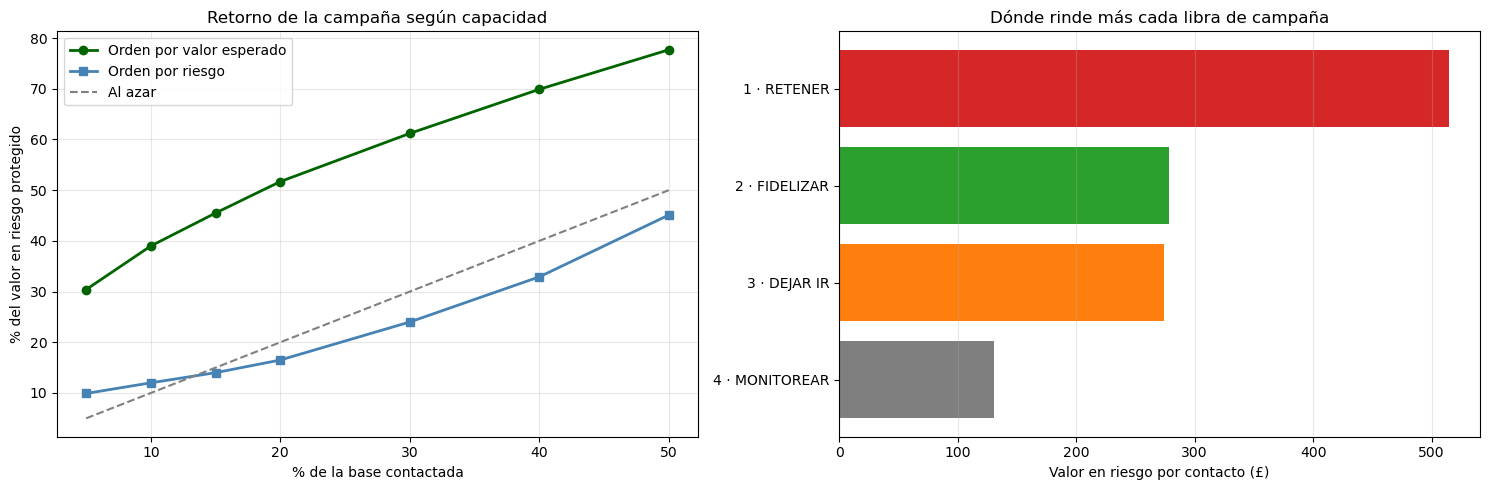

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

x = [int(c.strip('%')) for c in por_valor.index]
axes[0].plot(x, por_valor['% valor protegido'] * 100, marker='o', lw=2,
             label='Orden por valor esperado', color='darkgreen')
axes[0].plot(x, por_riesgo['% valor protegido'] * 100, marker='s', lw=2,
             label='Orden por riesgo', color='steelblue')
axes[0].plot(x, x, ls='--', color='gray', label='Al azar')
axes[0].set(xlabel='% de la base contactada', ylabel='% del valor en riesgo protegido',
            title='Retorno de la campaña según capacidad')
axes[0].legend(); axes[0].grid(alpha=0.3)

orden = cuadrantes.sort_index()
etiquetas = [p.split('—')[0].strip() for p in orden.index]
# Color indexado por número de cuadrante (no por posición): idéntico al de la Fase 3b
# y a prueba de reordenaciones de la tabla.
axes[1].barh(etiquetas[::-1], orden['£ en riesgo/obs'][::-1],
             color=[tfm.COLORES_CUADRANTE[p[0]] for p in orden.index][::-1])
axes[1].set(xlabel='Valor en riesgo por contacto (£)',
            title='Dónde rinde más cada libra de campaña')
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout(); plt.show()

### Limitaciones

1. **El horizonte es de 90 días, no *lifetime*.** El CLV estimado es el gasto del trimestre
   siguiente. Un CLV completo exigiría modelar la duración total de la relación (BG/NBD +
   Gamma-Gamma), fuera del alcance de este trabajo.

2. **Un 22,8% de las transacciones no tiene `Customer ID`** y queda fuera de todo el análisis.
   Es un volumen de ingresos real —el 14,3% de la facturación, £2,79 M— sobre el que no se
   puede actuar de forma personalizada.

3. **El poder predictivo tiene techo con features puramente transaccionales.** Los cuatro
   modelos quedan indistinguibles entre sí. Lo que falta no es un algoritmo mejor sino datos
   que el dataset no contiene: canal de captación, interacciones de servicio al cliente,
   respuesta a campañas anteriores, precio relativo frente a la competencia.

4. **`customer_age_days` mide antigüedad *dentro de la ventana*, no la antigüedad real del
   cliente.** Está acotada por construcción a la longitud de la ventana histórica (6 meses).
   Usar la antigüedad total desde la primera compra histórica probablemente aportaría señal
   adicional.

5. **La segmentación con K-Means asume grupos esféricos** en el espacio escalado. Un modelo
   de mezclas gaussianas daría fronteras más flexibles, y la elección de *k* seguiría siendo
   en parte un juicio de negocio.

6. **Las observaciones cliente-ventana no son independientes.** Un mismo cliente aparece en
   hasta 16 ventanas solapadas. La validación lo respeta —split temporal y CV agrupada por
   cliente—, pero cualquier suma directa sobre el panel (revenue, número de «clientes»)
   multiplica el valor real, y por eso el peso económico de los segmentos se calcula
   deduplicando por cliente.

7. **Dataset de un único negocio UK de regalos, 2009-2011.** Los coeficientes no son
   transferibles; la metodología sí.

8. **No hay validación causal.** El modelo predice quién se va, no si la campaña lo evita.
   Medir eso exige un test A/B con grupo de control. Todas las cifras de «valor protegido» son
   valor *identificado*, no valor *recuperado*.

### Líneas futuras

- **Test A/B de la campaña** sobre el cuadrante RETENER, con grupo de control, para medir el
  efecto incremental real de la intervención y no sólo la calidad de la predicción.
- **Uplift modelling** en vez de propensión: identificar a los clientes que cambian de
  comportamiento *porque* se les contacta, que no son necesariamente los de mayor riesgo.
- **CLV de horizonte completo** con BG/NBD + Gamma-Gamma, comparándolo con el proxy a 90 días.
- **Enriquecer el feature set** con categoría de producto, estacionalidad y datos de campaña.
- **Reentrenamiento periódico y monitorización de deriva**: la tasa de churn oscila entre el
  38% y el 62% según la ventana, así que un modelo congelado se degrada rápido.

### Cierre

El pipeline recorre el camino completo: de 1,07 millones de transacciones crudas a una
decisión de retención por cliente, con las tres preguntas encadenadas —quién se va, cuánto
vale, cómo se agrupa— y un prototipo que ejecuta esa cadena de principio a fin.

El resultado más útil del trabajo no es el modelo sino la disciplina de validación que lo
rodea: **un target que mira al futuro, un test temporal que no se solapa con el entrenamiento,
un modelo y un umbral elegidos sin mirar el test, y baselines que el modelo tiene que superar
para justificarse.**

Esa disciplina se construyó en tres rondas de corrección, cada una con una lente distinta.
La primera miró el **código**: un ROC-AUC de 0,79 y un R² de 0,83 que eran artefactos de un
target que miraba al pasado. La segunda cruzó el **código contra sí mismo**: una población que
incluía clientes que nunca compraron, un umbral y un modelo elegidos sobre el propio test, y un
reparto de ingresos que multiplicaba por cuatro la facturación real al sumar ventanas
solapadas. La tercera comparó **el texto contra los números**, y es la que más dice sobre el
oficio: afirmaciones heredadas de versiones anteriores que seguían escritas como si nada
hubiera cambiado. Un pipeline puede ser correcto y su relato ser falso, y por eso cada cifra
citada en prosa se comprueba ahora contra el resultado que la produce.

Cada corrección hizo bajar alguna métrica y ninguna hizo el trabajo menos útil: **las cifras
anteriores medían la capacidad del modelo para redescubrir información que ya tenía; las
actuales miden lo que se pretendía medir desde el principio.**

La lógica es transferible a cualquier programa de fidelización con transacciones repetidas
—aerolíneas, banca, telecomunicaciones—: cambian las variables, no la estructura.